# TASK 5 — Generate Main Indicator vs Probe Figure

**Goal**: Create the primary figure supporting the thesis claim that SSL embeddings preserve descriptor structure.

## Figure Structure

**Panel A (Scatter)**:
- x-axis: Linear probe R²
- y-axis: Indicator strength (effect_ratio, k=50, exclusive)
- Color: MLP gain (non-linearity)
- Label selected descriptors: MolWt, TPSA, LabuteASA, SMR_VSA*, PEOE_VSA*, Kappa3

**Panel B (Bars/Distributions)**:
- Compare NN |Δ| vs random |Δ| for 6–9 representative descriptors:
  - 3 high-linear (R² > 0.4)
  - 3 non-linear (MLP gain > 0.05)
  - 3 weak (R² < 0.1)

## Outputs
- `results/figures/indicator_vs_probe.png` (300 DPI)
- `results/figures/indicator_vs_probe.pdf` (vector)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib import cm
from pathlib import Path
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Try to import adjustText for automatic label positioning
try:
    from adjustText import adjust_text
    HAS_ADJUST_TEXT = True
    print("✓ adjustText available for automatic label positioning")
except ImportError:
    HAS_ADJUST_TEXT = False
    print("⚠️  adjustText not available - labels will be placed without overlap avoidance")
    print("   Install with: pip install adjustText")

# Set style
plt.style.use('seaborn-v0_8-paper')
sns.set_context('paper', font_scale=1.2)
sns.set_palette('colorblind')

print("✓ Imports complete")

✓ adjustText available for automatic label positioning
✓ Imports complete


## 1. Load Merged Data

In [3]:
# Paths
results_dir = Path('../results')
indicators_dir = results_dir / 'indicators'
figures_dir = results_dir / 'figures'
figures_dir.mkdir(parents=True, exist_ok=True)

print(f"Results directory: {results_dir}")
print(f"Figures directory: {figures_dir}")

Results directory: ../results
Figures directory: ../results/figures


In [4]:
# Load merged probe-indicator data from TASK 4
print("Loading merged data...")

merged_path = indicators_dir / 'probe_indicator_merged.csv'
df = pd.read_csv(merged_path)

print(f"  ✓ Loaded: {merged_path}")
print(f"  Shape: {df.shape}")
print(f"  Columns: {df.columns.tolist()}")

# Drop rows with missing data for visualization
df_clean = df.dropna(subset=['r2_linear', 'effect_ratio', 'mlp_gain'])
print(f"\n  Clean data (no NaN): {df_clean.shape[0]} descriptors")

Loading merged data...
  ✓ Loaded: ../results/indicators/probe_indicator_merged.csv
  Shape: (201, 21)
  Columns: ['descriptor', 'r2', 'mae', 'n_train', 'n_test', 'train_mean', 'train_std', 'test_mean', 'test_std', 'r2_linear', 'mae_linear', 'r2_mlp', 'mae_mlp', 'effect_ratio', 'spearman_corr', 'nn_mean_diff', 'random_mean_diff', 'mlp_gain', 'flag_high_linear', 'flag_nonlinear', 'flag_low_probe_strong_indicator']

  Clean data (no NaN): 201 descriptors


## 2. Select Representative Descriptors

In [5]:
# Define categories
print("Selecting representative descriptors...\n")

# High-linear: R² > 0.4
high_linear = df_clean[df_clean['r2_linear'] > 0.4].nlargest(3, 'r2_linear')
print("High-linear (top 3 by R²):")
print(high_linear[['descriptor', 'r2_linear', 'effect_ratio', 'mlp_gain']].to_string(index=False))

# Non-linear: MLP gain > 0.05
nonlinear = df_clean[df_clean['mlp_gain'] > 0.05].nlargest(3, 'mlp_gain')
print("\nNon-linear (top 3 by MLP gain):")
print(nonlinear[['descriptor', 'r2_linear', 'effect_ratio', 'mlp_gain']].to_string(index=False))

# Weak: R² < 0.1
weak = df_clean[df_clean['r2_linear'] < 0.1].nsmallest(3, 'r2_linear')
print("\nWeak (bottom 3 by R²):")
print(weak[['descriptor', 'r2_linear', 'effect_ratio', 'mlp_gain']].to_string(index=False))

# Combine for Panel B
representative = pd.concat([high_linear, nonlinear, weak])
print(f"\n  Total representative descriptors: {len(representative)}")

Selecting representative descriptors...

High-linear (top 3 by R²):
    descriptor  r2_linear  effect_ratio  mlp_gain
          Chi0   0.445562      2.109216  0.093801
HeavyAtomMolWt   0.432720      2.096897  0.068368
      SMR_VSA1   0.421478      1.817499  0.026119

Non-linear (top 3 by MLP gain):
       descriptor  r2_linear  effect_ratio  mlp_gain
           Kappa3  -4.806458      1.670233  4.853348
 fr_unbrch_alkane  -3.197744      1.289908  3.037741
fr_term_acetylene  -2.037137      0.838502  1.547160

Weak (bottom 3 by R²):
       descriptor  r2_linear  effect_ratio  mlp_gain
           Kappa3  -4.806458      1.670233  4.853348
 fr_unbrch_alkane  -3.197744      1.289908  3.037741
fr_term_acetylene  -2.037137      0.838502  1.547160

  Total representative descriptors: 9


In [6]:
# Descriptors to label in Panel A (simplified - only 5 key descriptors)
label_descriptors = [
    'MolWt',
    'TPSA', 
    'LabuteASA',
    'SMR_VSA5',
    'Kappa1'
]

# Check which are present
label_descriptors_present = [d for d in label_descriptors if d in df_clean['descriptor'].values]
print(f"\nLabeled descriptors for Panel A: {len(label_descriptors_present)}")
print(label_descriptors_present)


Labeled descriptors for Panel A: 5
['MolWt', 'TPSA', 'LabuteASA', 'SMR_VSA5', 'Kappa1']


## 3. Panel A — Scatter Plot

✓ Panel A complete


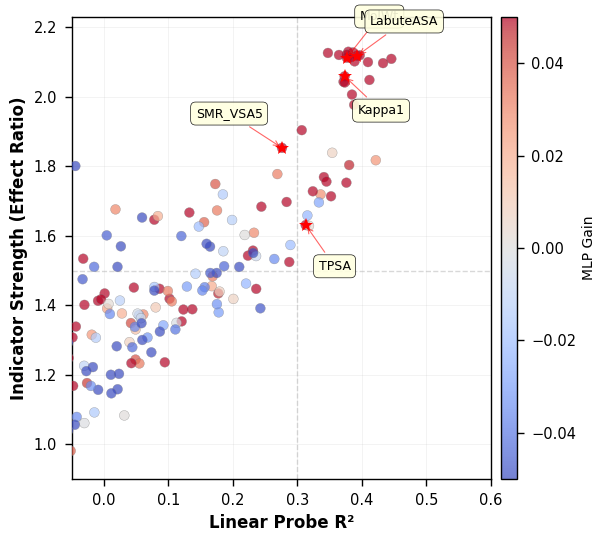

In [7]:
# Create figure with 2 panels
fig = plt.figure(figsize=(15, 6))
gs = fig.add_gridspec(1, 2, width_ratios=[1, 1], wspace=0.3)

# Panel A: Scatter plot
ax_scatter = fig.add_subplot(gs[0, 0])

# Prepare data
x = df_clean['r2_linear']
y = df_clean['effect_ratio']
c = df_clean['mlp_gain']

# Create scatter plot with simpler styling
scatter = ax_scatter.scatter(
    x, y, c=c, 
    s=50, alpha=0.7, 
    cmap='coolwarm',
    vmin=-0.05, vmax=0.05,
    edgecolors='gray', linewidths=0.3,
    zorder=3
)

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax_scatter, pad=0.02, aspect=30)
cbar.set_label('MLP Gain', fontsize=10)

# Add reference lines for quadrants
ax_scatter.axhline(1.5, color='gray', linestyle='--', alpha=0.3, linewidth=1, zorder=1)
ax_scatter.axvline(0.3, color='gray', linestyle='--', alpha=0.3, linewidth=1, zorder=1)

# Labels and title
ax_scatter.set_xlabel('Linear Probe R²', fontsize=12, fontweight='bold')
ax_scatter.set_ylabel('Indicator Strength (Effect Ratio)', fontsize=12, fontweight='bold')


# Set limits
ax_scatter.set_xlim(-0.05, 0.6)
ax_scatter.set_ylim(0.9, df_clean['effect_ratio'].max() + 0.1)

# Grid
ax_scatter.grid(True, alpha=0.2, zorder=0, linewidth=0.5)

# Annotate key descriptors with manual offsets for better placement
label_offsets = {
    'MolWt': (0.02, 0.1),
    'TPSA': (0.02, -0.1),
    'LabuteASA': (0.02, 0.08),
    'SMR_VSA5': (-0.03, 0.08),
    'Kappa1': (0.02, -0.08)
}

for desc in label_descriptors_present:
    row = df_clean[df_clean['descriptor'] == desc].iloc[0]
    offset = label_offsets.get(desc, (0.01, 0.05))
    
    # Plot a small marker for the labeled point
    ax_scatter.plot(row['r2_linear'], row['effect_ratio'], 
                   'r*', markersize=10, zorder=5)
    
    # Add text with offset
    ax_scatter.annotate(
        desc,
        xy=(row['r2_linear'], row['effect_ratio']),
        xytext=(row['r2_linear'] + offset[0], row['effect_ratio'] + offset[1]),
        fontsize=9,
        bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', alpha=0.9, edgecolor='black', linewidth=0.5),
        ha='left' if offset[0] > 0 else 'right',
        va='bottom' if offset[1] > 0 else 'top',
        zorder=10,
        arrowprops=dict(arrowstyle='->', lw=0.8, color='red', alpha=0.6)
    )

print("✓ Panel A complete")

## 4. Panel B — NN vs Random Comparison

In [8]:
# Panel B: Simplified bar chart comparing NN vs random
ax_bars = fig.add_subplot(gs[0, 1])

# Prepare data for representative descriptors
rep_data = representative[['descriptor', 'nn_mean_diff', 'random_mean_diff', 'effect_ratio']].copy()
rep_data = rep_data.sort_values('effect_ratio', ascending=False)

# Limit to top 6 for clarity
rep_data = rep_data.head(6)

# Create bar positions
n_desc = len(rep_data)
x_pos = np.arange(n_desc)
bar_width = 0.35

# Plot bars with simpler colors
bars_nn = ax_bars.barh(
    x_pos - bar_width/2, 
    rep_data['nn_mean_diff'], 
    bar_width, 
    label='NN Pairs',
    color='steelblue', alpha=0.8, edgecolor='black', linewidth=0.5
)

bars_random = ax_bars.barh(
    x_pos + bar_width/2, 
    rep_data['random_mean_diff'], 
    bar_width, 
    label='Random Pairs',
    color='coral', alpha=0.8, edgecolor='black', linewidth=0.5
)

# Add effect ratio as text
for i, (idx, row) in enumerate(rep_data.iterrows()):
    ratio = row['effect_ratio']
    max_val = max(row['nn_mean_diff'], row['random_mean_diff'])
    ax_bars.text(
        max_val * 1.05, i, 
        f"{ratio:.2f}×",
        va='center', ha='left', fontsize=9,
        color='darkgreen' if ratio > 1.5 else 'darkgray'
    )

# Labels
ax_bars.set_yticks(x_pos)
ax_bars.set_yticklabels(rep_data['descriptor'], fontsize=10)
ax_bars.set_xlabel('Mean |Δ Descriptor|', fontsize=11, fontweight='bold')
ax_bars.set_title('B. NN Consistency (Top 6)', 
                   fontsize=13, fontweight='bold', pad=10)

# Invert y-axis to show best at top
ax_bars.invert_yaxis()

# Legend
ax_bars.legend(loc='lower right', fontsize=9, framealpha=0.9)

# Grid
ax_bars.grid(axis='x', alpha=0.3, linewidth=0.5)

print("✓ Panel B complete")

✓ Panel B complete


## 5. Add Figure Annotations

In [9]:
# Add overall figure title
fig.suptitle(
    'SSL Embedding Quality: Probe Performance vs Indicator Strength',
    fontsize=14, fontweight='bold', y=0.98
)

# Add correlation text to Panel A
corr = df_clean[['r2_linear', 'effect_ratio']].corr().iloc[0, 1]
ax_scatter.text(
    0.98, 0.02, 
    f'Pearson r = {corr:.3f}\nn = {len(df_clean)}',
    transform=ax_scatter.transAxes,
    fontsize=10, va='bottom', ha='right',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='black', linewidth=0.5)
)

print(f"✓ Correlation r = {corr:.3f}")
print("✓ Annotations complete")

✓ Correlation r = 0.262
✓ Annotations complete


## 6. Save Figure

In [10]:
# Save as PNG (high resolution)
png_path = figures_dir / 'indicator_vs_probe.png'
fig.savefig(png_path, dpi=300, bbox_inches='tight', facecolor='white')
print(f"✓ Saved PNG: {png_path}")

# Save as PDF (vector)
pdf_path = figures_dir / 'indicator_vs_probe.pdf'
fig.savefig(pdf_path, bbox_inches='tight', facecolor='white')
print(f"✓ Saved PDF: {pdf_path}")

plt.show()

print(f"\n{'='*80}")
print("TASK 5 COMPLETE — Main Figure Generated")
print(f"{'='*80}")
print(f"\nFigures saved to:")
print(f"  - {png_path}")
print(f"  - {pdf_path}")

✓ Saved PNG: ../results/figures/indicator_vs_probe.png
✓ Saved PDF: ../results/figures/indicator_vs_probe.pdf

TASK 5 COMPLETE — Main Figure Generated

Figures saved to:
  - ../results/figures/indicator_vs_probe.png
  - ../results/figures/indicator_vs_probe.pdf


## 7. Summary Statistics

In [11]:
# Print summary statistics for thesis
print("\n" + "="*80)
print("SUMMARY STATISTICS FOR THESIS")
print("="*80)

print(f"\nOverall Metrics (n={len(df_clean)}):")
print(f"  Pearson correlation (R² vs ratio): {corr:.3f}")
print(f"  Mean R² (linear probe): {df_clean['r2_linear'].mean():.4f}")
print(f"  Mean effect ratio: {df_clean['effect_ratio'].mean():.4f}")
print(f"  Mean MLP gain: {df_clean['mlp_gain'].mean():.4f}")

print(f"\nDescriptor Categories:")
high_cat = (df_clean['r2_linear'] > 0.3).sum()
strong_ind = (df_clean['effect_ratio'] > 1.5).sum()
both_strong = ((df_clean['r2_linear'] > 0.3) & (df_clean['effect_ratio'] > 1.5)).sum()

print(f"  High linear probe (R² > 0.3): {high_cat} ({high_cat/len(df_clean)*100:.1f}%)")
print(f"  Strong indicator (ratio > 1.5): {strong_ind} ({strong_ind/len(df_clean)*100:.1f}%)")
print(f"  Both high probe AND strong indicator: {both_strong} ({both_strong/len(df_clean)*100:.1f}%)")

print(f"\nNon-linearity:")
nonlin_count = (df_clean['mlp_gain'] > 0.05).sum()
print(f"  Descriptors with MLP gain > 0.05: {nonlin_count} ({nonlin_count/len(df_clean)*100:.1f}%)")
print(f"  Max MLP gain: {df_clean['mlp_gain'].max():.4f} ({df_clean.loc[df_clean['mlp_gain'].idxmax(), 'descriptor']})")

print("\n" + "="*80)


SUMMARY STATISTICS FOR THESIS

Overall Metrics (n=201):
  Pearson correlation (R² vs ratio): 0.262
  Mean R² (linear probe): 0.0070
  Mean effect ratio: 1.4412
  Mean MLP gain: 0.0959

Descriptor Categories:
  High linear probe (R² > 0.3): 33 (16.4%)
  Strong indicator (ratio > 1.5): 77 (38.3%)
  Both high probe AND strong indicator: 33 (16.4%)

Non-linearity:
  Descriptors with MLP gain > 0.05: 76 (37.8%)
  Max MLP gain: 4.8533 (Kappa3)



## 8. Standalone Scatter Plot — No Title, Auto-Positioned Labels

✓ Standalone scatter plot created


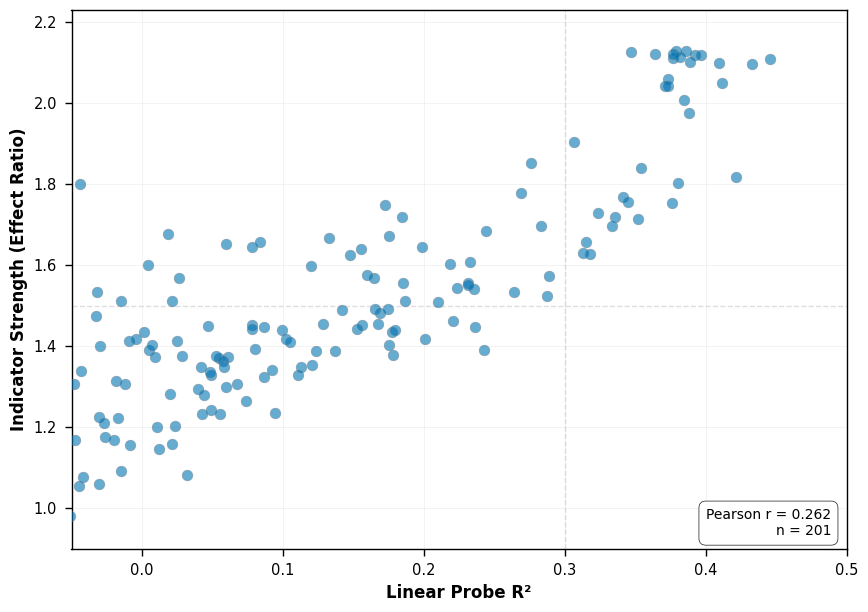

In [56]:
# Create standalone scatter figure (no overall title, auto-positioned labels)
fig_standalone, ax = plt.subplots(figsize=(10, 7))

# Prepare data
x = df_clean['r2_linear']
y = df_clean['effect_ratio']
c = df_clean['mlp_gain']

# Create scatter plot
scatter = ax.scatter(
    x, y,
    s=60, alpha=0.6, 
    cmap='coolwarm',
    vmin=-0.05, vmax=0.05,
    edgecolors='gray', linewidths=0.4,
    zorder=3
)

# Add colorbar
#cbar = plt.colorbar(scatter, ax=ax, pad=0.02, aspect=30)
#cbar.set_label('MLP Gain', fontsize=11, fontweight='bold')

# Add reference lines for quadrants
ax.axhline(1.5, color='gray', linestyle='--', alpha=0.25, linewidth=1, zorder=1)
ax.axvline(0.3, color='gray', linestyle='--', alpha=0.25, linewidth=1, zorder=1)

# Labels (no overall title)
ax.set_xlabel('Linear Probe R²', fontsize=12, fontweight='bold')
ax.set_ylabel('Indicator Strength (Effect Ratio)', fontsize=12, fontweight='bold')

# Set limits
ax.set_xlim(-0.05, 0.5)
ax.set_ylim(0.9, df_clean['effect_ratio'].max() + 0.1)

# Grid
ax.grid(True, alpha=0.2, zorder=0, linewidth=0.5)

# Add correlation text
corr = df_clean[['r2_linear', 'effect_ratio']].corr().iloc[0, 1]
ax.text(
    0.98, 0.02, 
    f'Pearson r = {corr:.3f}\nn = {len(df_clean)}',
    transform=ax.transAxes,
    fontsize=10, va='bottom', ha='right',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='black', linewidth=0.5)
)

print("✓ Standalone scatter plot created")

In [57]:
# Add descriptors with automatic non-overlapping label positioning
label_descriptors = ['MolWt', 'TPSA', 'SMR_VSA5', 'Kappa1']
label_descriptors_present = [d for d in label_descriptors if d in df_clean['descriptor'].values]

print(f"Annotating {len(label_descriptors_present)} descriptors: {label_descriptors_present}")

# Remove any existing annotations/extra artists to avoid duplicates
for artist in ax.texts[:]:
    artist.remove()

# Small offsets in DATA coordinates (x_offset, y_offset) + alignment
# ha/va control which side of the text box anchors to the offset position
label_config = {
    'MolWt':    {'dx': -0.02, 'dy': 0.02, 'ha': 'right', 'va': 'bottom'},
    'TPSA':     {'dx':  0.02, 'dy': 0.02, 'ha': 'left',  'va': 'bottom'},
    'SMR_VSA5': {'dx':  0.02, 'dy':-0.02, 'ha': 'left',  'va': 'top'},
    'Kappa1':   {'dx':  0.02, 'dy': 0.00, 'ha': 'left',  'va': 'center'},
}

for desc in label_descriptors_present:
    row = df_clean[df_clean['descriptor'] == desc].iloc[0]
    x_pos = row['r2_linear']
    y_pos = row['effect_ratio']
    
    # Plot star marker at data point
    ax.plot(x_pos, y_pos, 'r*', markersize=18, zorder=6, markeredgecolor='darkred', markeredgewidth=0.5)
    
    # Place label directly in data coordinates right next to the point
    cfg = label_config.get(desc, {'dx': 0.02, 'dy': 0, 'ha': 'left', 'va': 'center'})
    ax.text(
        x_pos + cfg['dx'], y_pos + cfg['dy'],
        desc,
        fontsize=9,
        fontweight='bold',
        ha=cfg['ha'], va=cfg['va'],
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.9, edgecolor='black', linewidth=0.6),
        zorder=10
    )

plt.tight_layout()
print("✓ Standalone figure complete")

Annotating 4 descriptors: ['MolWt', 'TPSA', 'SMR_VSA5', 'Kappa1']
✓ Standalone figure complete


<Figure size 640x440 with 0 Axes>

In [58]:
# Save standalone scatter plot
png_standalone_path = figures_dir / 'scatter_standalone.png'
fig_standalone.savefig(png_standalone_path, dpi=300, bbox_inches='tight', facecolor='white')
print(f"✓ Saved PNG: {png_standalone_path}")

pdf_standalone_path = figures_dir / 'scatter_standalone.pdf'
fig_standalone.savefig(pdf_standalone_path, bbox_inches='tight', facecolor='white')
print(f"✓ Saved PDF: {pdf_standalone_path}")

plt.show()

print(f"\n{'='*80}")
print("STANDALONE SCATTER PLOT SAVED")
print(f"{'='*80}")
print(f"\nFiles saved:")
print(f"  - {png_standalone_path}")
print(f"  - {pdf_standalone_path}")

✓ Saved PNG: ../results/figures/scatter_standalone.png
✓ Saved PDF: ../results/figures/scatter_standalone.pdf

STANDALONE SCATTER PLOT SAVED

Files saved:
  - ../results/figures/scatter_standalone.png
  - ../results/figures/scatter_standalone.pdf
